# EDA -- SeaDronesSee (RGB Drone Dataset)

**SeaDronesSee**: Object detection from drones over water.
- COCO JSON annotations
- Classes: ignored(0), swimmer(1), boat(2), jetski(3), life_saving_appliances(4), buoy(5)
- Trong project: chi dung swimmer -> map ve class 0 (person)
- Dung de pretrain RGB backbone (Luong 1)

## 1. Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter

SDS_DIR = '../RGB/data/seadronessee/compressed'
TRAIN_IMG = os.path.join(SDS_DIR, 'images', 'train')
VAL_IMG   = os.path.join(SDS_DIR, 'images', 'val')
TRAIN_ANN = os.path.join(SDS_DIR, 'annotations', 'instances_train.json')
VAL_ANN   = os.path.join(SDS_DIR, 'annotations', 'instances_val.json')

print(f'Train images: {len(os.listdir(TRAIN_IMG))}')
print(f'Val images:   {len(os.listdir(VAL_IMG))}')


Train images: 8930
Val images:   1547


## 2. Parse Annotations

In [2]:
def load_coco(json_path, split):
    with open(json_path) as f:
        coco = json.load(f)
    id2img = {img['id']: img for img in coco['images']}
    id2cat = {c['id']: c['name'] for c in coco['categories']}
    rows = []
    for ann in coco['annotations']:
        img = id2img[ann['image_id']]
        x, y, w, h = ann['bbox']
        rows.append({
            'split': split,
            'file_name': img['file_name'],
            'img_w': img['width'], 'img_h': img['height'],
            'cat_id': ann['category_id'],
            'cat_name': id2cat[ann['category_id']],
            'bbox_x': x, 'bbox_y': y, 'bbox_w': w, 'bbox_h': h,
            'area': ann['area'],
        })
    return rows, coco['categories']

train_rows, categories = load_coco(TRAIN_ANN, 'train')
val_rows, _ = load_coco(VAL_ANN, 'val')
df = pd.DataFrame(train_rows + val_rows)

print(f'Total annotations: {len(df)}')
print(f'Categories: {categories}')
print(f'\nPer class:')
print(df.groupby(['split', 'cat_name']).size().unstack(fill_value=0))


Total annotations: 67390
Categories: [{'supercategory': 'ignored', 'id': 0, 'name': 'ignored'}, {'supercategory': 'person', 'id': 1, 'name': 'swimmer'}, {'supercategory': 'boat', 'id': 2, 'name': 'boat'}, {'supercategory': 'boat', 'id': 3, 'name': 'jetski'}, {'supercategory': 'object', 'id': 4, 'name': 'life_saving_appliances'}, {'supercategory': 'object', 'id': 5, 'name': 'buoy'}]

Per class:
cat_name   boat  buoy  jetski  life_saving_appliances  swimmer
split                                                         
train     13022  4389    2330                     923    37096
val        2214   560     320                     330     6206


## 3. Dataset Overview

In [3]:
n_train = df[df['split']=='train']['file_name'].nunique()
n_val   = df[df['split']=='val']['file_name'].nunique()

print('=' * 50)
print('SeaDronesSee Dataset Summary')
print('=' * 50)
print(f'Total images:    {n_train + n_val}')
print(f'  Train:         {n_train}')
print(f'  Val:           {n_val}')
print(f'Total annot:     {len(df)}')
print(f'  Train annot:   {len(df[df["split"]=="train"])}')
print(f'  Val annot:     {len(df[df["split"]=="val"])}')
print(f'\nClass distribution:')
print(df['cat_name'].value_counts())

# Swimmer only (person class)
df_person = df[df['cat_name'] == 'swimmer'].copy()
print(f'\nSwimmer (person) only: {len(df_person)} annotations')
print(f'Avg swimmers/image: {len(df_person) / df_person["file_name"].nunique():.2f}')


SeaDronesSee Dataset Summary
Total images:    10477
  Train:         8930
  Val:           1547
Total annot:     67390
  Train annot:   57760
  Val annot:     9630

Class distribution:
cat_name
swimmer                   43302
boat                      15236
buoy                       4949
jetski                     2650
life_saving_appliances     1253
Name: count, dtype: int64

Swimmer (person) only: 43302 annotations
Avg swimmers/image: 5.29


## 4. Class Distribution (Bar Chart)

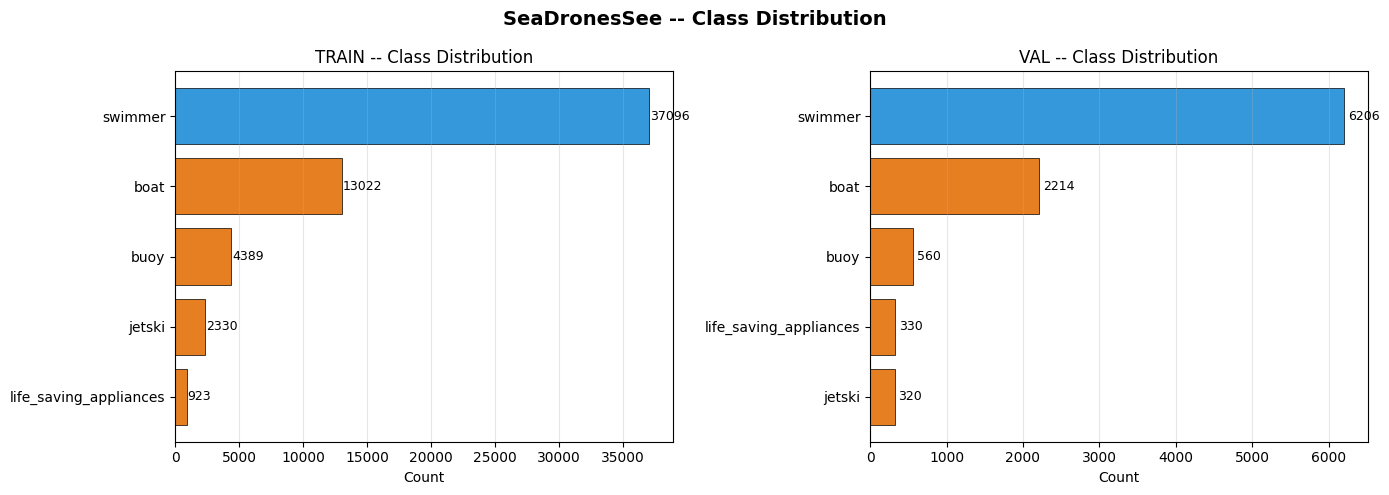

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ['train', 'val']):
    sub = df[df['split'] == split]
    counts = sub['cat_name'].value_counts().sort_values(ascending=True)
    colors = ['#95a5a6' if c == 'ignored' else '#3498db' if c == 'swimmer'
              else '#e67e22' for c in counts.index]
    ax.barh(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
    for i, v in enumerate(counts.values):
        ax.text(v + 50, i, str(v), va='center', fontsize=9)
    ax.set_title(f'{split.upper()} -- Class Distribution', fontsize=12)
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('SeaDronesSee -- Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Persons (Swimmer) Per Image

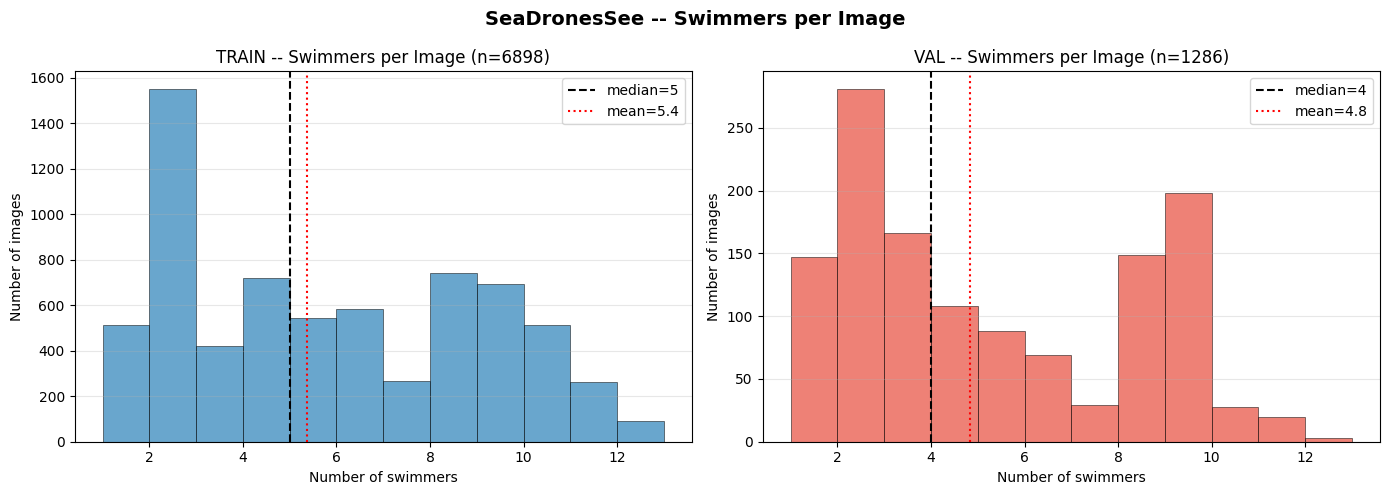


Swimmers per image stats:
        count  mean   std  min  25%  50%  75%   max
split                                              
train  6898.0  5.38  3.18  1.0  2.0  5.0  8.0  12.0
val    1286.0  4.83  3.04  1.0  2.0  4.0  8.0  12.0


In [5]:
per_img = df_person.groupby(['split', 'file_name']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ['train', 'val']):
    data = per_img[per_img['split'] == split]['count']
    ax.hist(data, bins=range(1, min(data.max()+2, 50)), alpha=0.7,
            color='#2980b9' if split == 'train' else '#e74c3c',
            edgecolor='black', linewidth=0.5)
    ax.set_title(f'{split.upper()} -- Swimmers per Image (n={len(data)})', fontsize=12)
    ax.set_xlabel('Number of swimmers')
    ax.set_ylabel('Number of images')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'median={data.median():.0f}')
    ax.axvline(data.mean(), color='red', linestyle=':', linewidth=1.5,
               label=f'mean={data.mean():.1f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SeaDronesSee -- Swimmers per Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSwimmers per image stats:')
print(per_img.groupby('split')['count'].describe().round(2))


## 6. Bounding Box Size Distribution

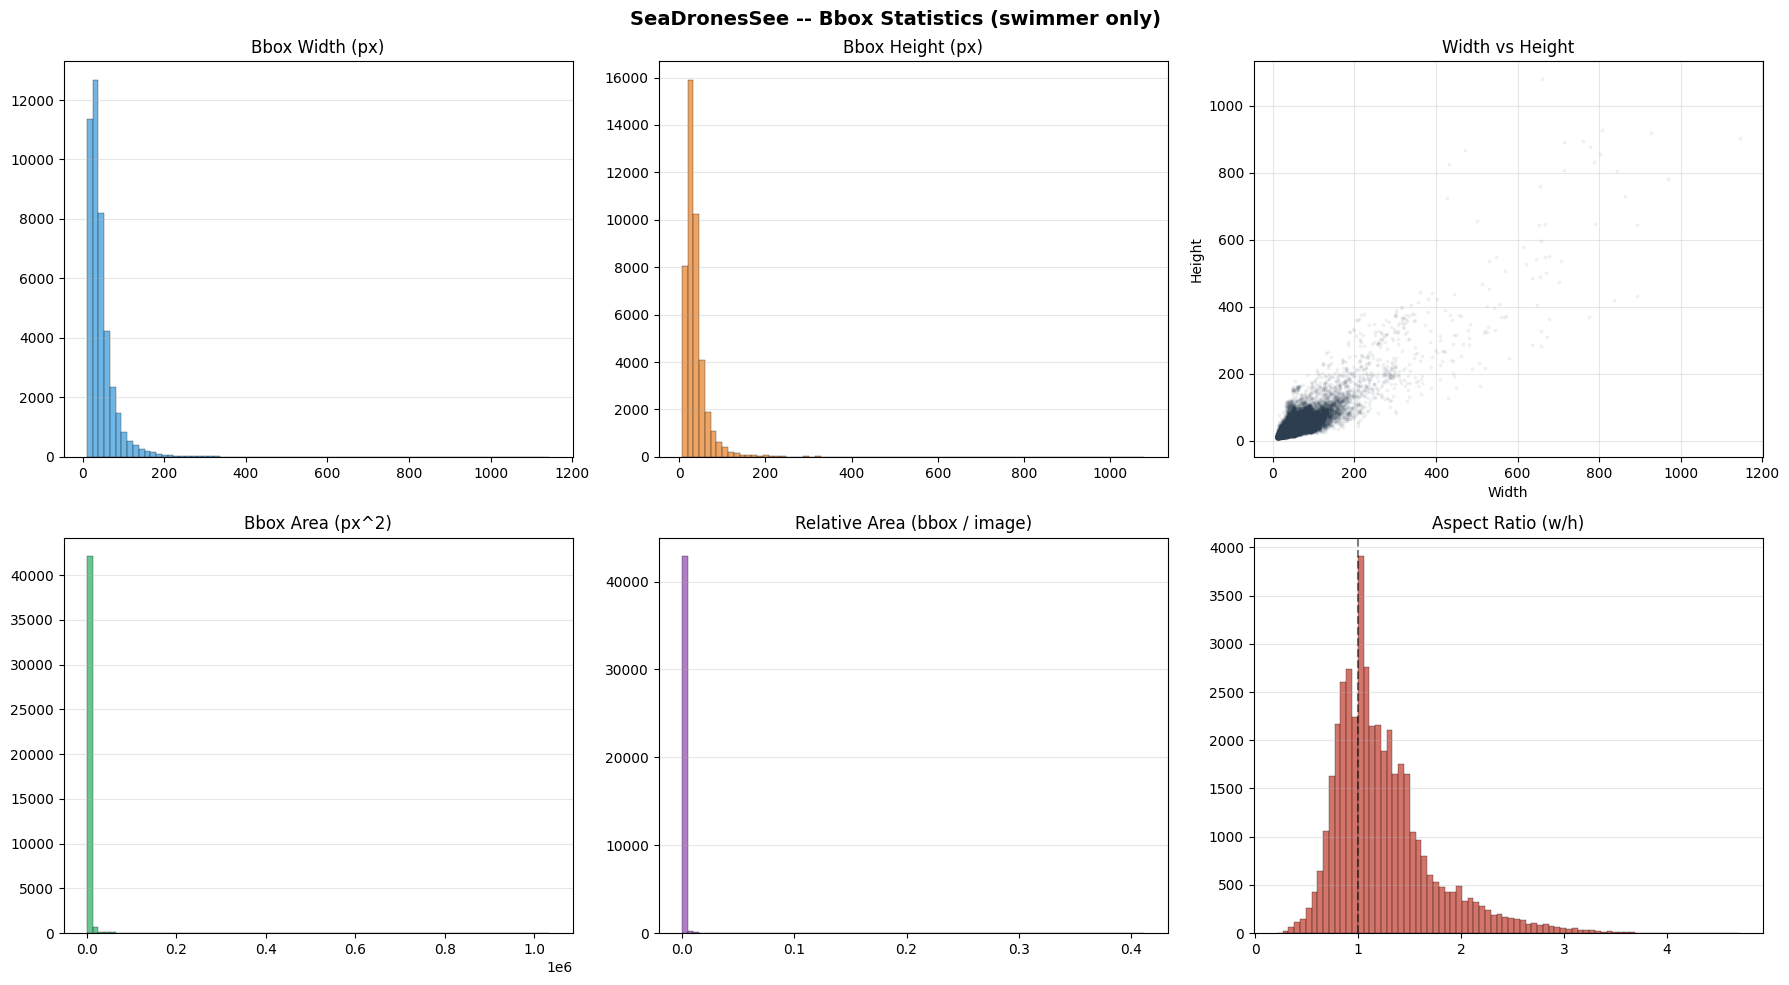


Bbox stats (swimmer):
         bbox_w    bbox_h        area  rel_area  aspect_ratio
count  43302.00  43302.00    43302.00  43302.00      43302.00
mean      46.11     38.34     3138.60      0.00          1.25
std       43.77     36.50    17818.79      0.01          0.48
min       10.00      6.00       90.00      0.00          0.21
25%       24.00     22.00      529.00      0.00          0.92
50%       36.00     30.00     1092.00      0.00          1.13
75%       53.00     43.00     2254.00      0.00          1.44
max     1144.00   1079.00  1034176.00      0.41          4.70


In [6]:
df_person['rel_area'] = (df_person['bbox_w'] * df_person['bbox_h']) / (df_person['img_w'] * df_person['img_h'])
df_person['aspect_ratio'] = df_person['bbox_w'] / df_person['bbox_h'].clip(lower=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df_person['bbox_w'], bins=80, alpha=0.7, color='#3498db', edgecolor='black', linewidth=0.3)
axes[0,0].set_title('Bbox Width (px)'); axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].hist(df_person['bbox_h'], bins=80, alpha=0.7, color='#e67e22', edgecolor='black', linewidth=0.3)
axes[0,1].set_title('Bbox Height (px)'); axes[0,1].grid(axis='y', alpha=0.3)

axes[0,2].scatter(df_person['bbox_w'], df_person['bbox_h'], alpha=0.05, s=3, c='#2c3e50')
axes[0,2].set_title('Width vs Height')
axes[0,2].set_xlabel('Width'); axes[0,2].set_ylabel('Height'); axes[0,2].grid(alpha=0.3)

axes[1,0].hist(df_person['area'], bins=80, alpha=0.7, color='#27ae60', edgecolor='black', linewidth=0.3)
axes[1,0].set_title('Bbox Area (px^2)'); axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].hist(df_person['rel_area'], bins=80, alpha=0.7, color='#8e44ad', edgecolor='black', linewidth=0.3)
axes[1,1].set_title('Relative Area (bbox / image)'); axes[1,1].grid(axis='y', alpha=0.3)

axes[1,2].hist(df_person['aspect_ratio'], bins=80, alpha=0.7, color='#c0392b', edgecolor='black', linewidth=0.3)
axes[1,2].set_title('Aspect Ratio (w/h)'); axes[1,2].grid(axis='y', alpha=0.3)
axes[1,2].axvline(1.0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('SeaDronesSee -- Bbox Statistics (swimmer only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBbox stats (swimmer):')
print(df_person[['bbox_w','bbox_h','area','rel_area','aspect_ratio']].describe().round(2))


## 7. Bbox Center Heatmap

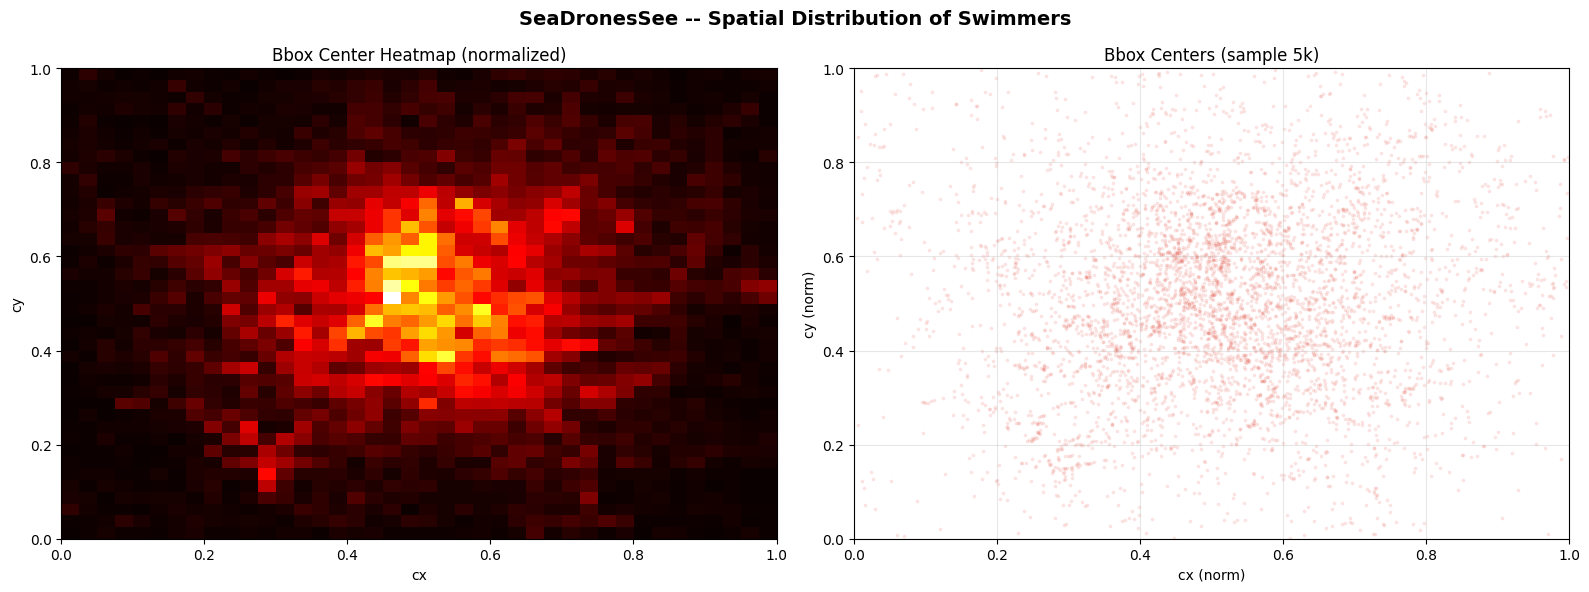

In [7]:
df_person['cx'] = df_person['bbox_x'] + df_person['bbox_w'] / 2
df_person['cy'] = df_person['bbox_y'] + df_person['bbox_h'] / 2
df_person['cx_norm'] = df_person['cx'] / df_person['img_w']
df_person['cy_norm'] = df_person['cy'] / df_person['img_h']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

heatmap, xedges, yedges = np.histogram2d(
    df_person['cx_norm'], df_person['cy_norm'],
    bins=40, range=[[0,1],[0,1]]
)
axes[0].imshow(heatmap.T, origin='lower', extent=[0,1,0,1], cmap='hot', aspect='auto')
axes[0].set_title('Bbox Center Heatmap (normalized)')
axes[0].set_xlabel('cx'); axes[0].set_ylabel('cy')

sample = df_person.sample(min(5000, len(df_person)), random_state=42)
axes[1].scatter(sample['cx_norm'], sample['cy_norm'], alpha=0.1, s=3, c='#e74c3c')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_title('Bbox Centers (sample 5k)')
axes[1].set_xlabel('cx (norm)'); axes[1].set_ylabel('cy (norm)')
axes[1].grid(alpha=0.3)

plt.suptitle('SeaDronesSee -- Spatial Distribution of Swimmers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Small / Medium / Large Object Distribution (COCO standard)

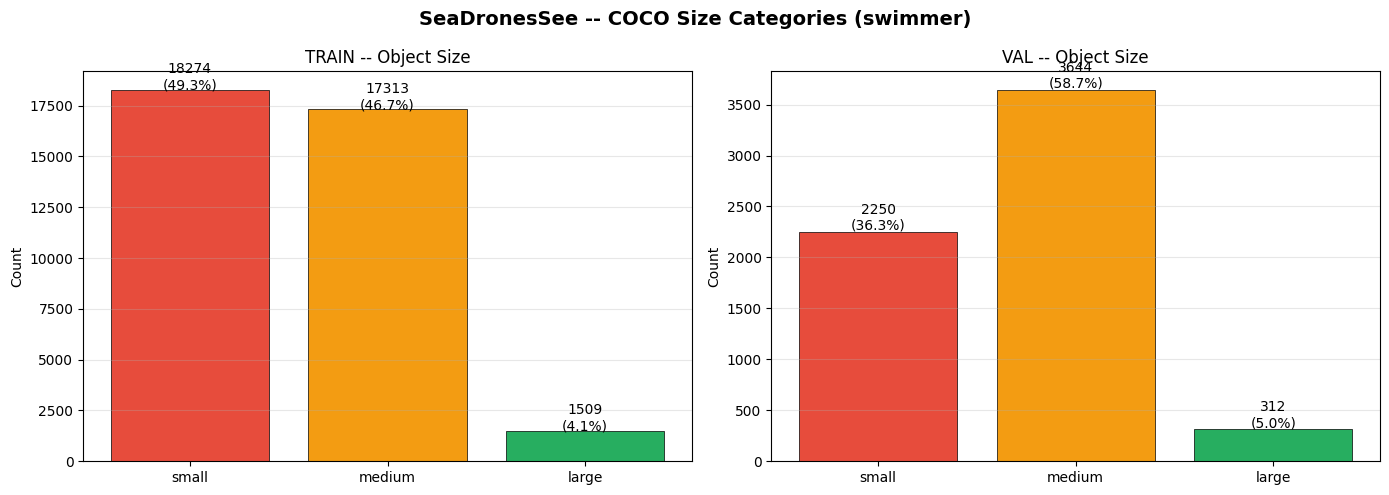


Size distribution:
size_cat  large  medium  small
split                         
train      1509   17313  18274
val         312    3644   2250


In [8]:
def size_cat(area):
    if area < 1024: return 'small'
    elif area < 9216: return 'medium'
    else: return 'large'

df_person['size_cat'] = df_person['area'].apply(size_cat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'small': '#e74c3c', 'medium': '#f39c12', 'large': '#27ae60'}

for ax, split in zip(axes, ['train', 'val']):
    subset = df_person[df_person['split'] == split]
    counts = subset['size_cat'].value_counts().reindex(['small','medium','large'], fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[colors[c] for c in counts.index], edgecolor='black', linewidth=0.5)
    ax.set_title(f'{split.upper()} -- Object Size', fontsize=12)
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, counts.values):
        pct = val / max(len(subset), 1) * 100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{val}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.suptitle('SeaDronesSee -- COCO Size Categories (swimmer)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSize distribution:')
print(df_person.groupby(['split','size_cat']).size().unstack(fill_value=0))


## 9. Image Resolution Distribution

Image resolutions:
   w    h  count
3840 2160   6830
1920 1080   1834
5456 3632   1009
3632 5456    329
1230  933    139
1231  933    124
1231  934     91
1230  934     42
1230  932     28
1232  934     16


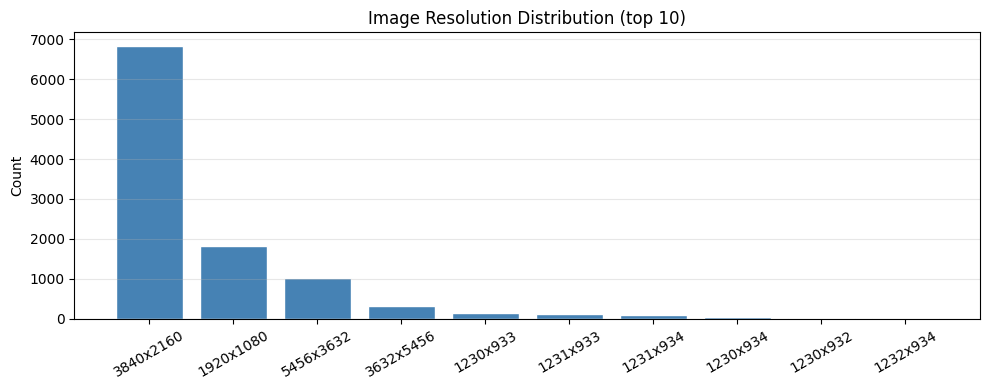

In [9]:
with open(TRAIN_ANN) as f:
    train_coco = json.load(f)
with open(VAL_ANN) as f:
    val_coco = json.load(f)

all_imgs = train_coco['images'] + val_coco['images']
img_df = pd.DataFrame([{'w': i['width'], 'h': i['height']} for i in all_imgs])
res = img_df.groupby(['w','h']).size().reset_index(name='count').sort_values('count', ascending=False)

print('Image resolutions:')
print(res.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f'{r.w}x{r.h}' for _, r in res.head(10).iterrows()]
ax.bar(labels, res['count'].values[:10], color='steelblue', edgecolor='white')
ax.set_title('Image Resolution Distribution (top 10)')
ax.set_ylabel('Count'); plt.xticks(rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Sample Images (with bbox)

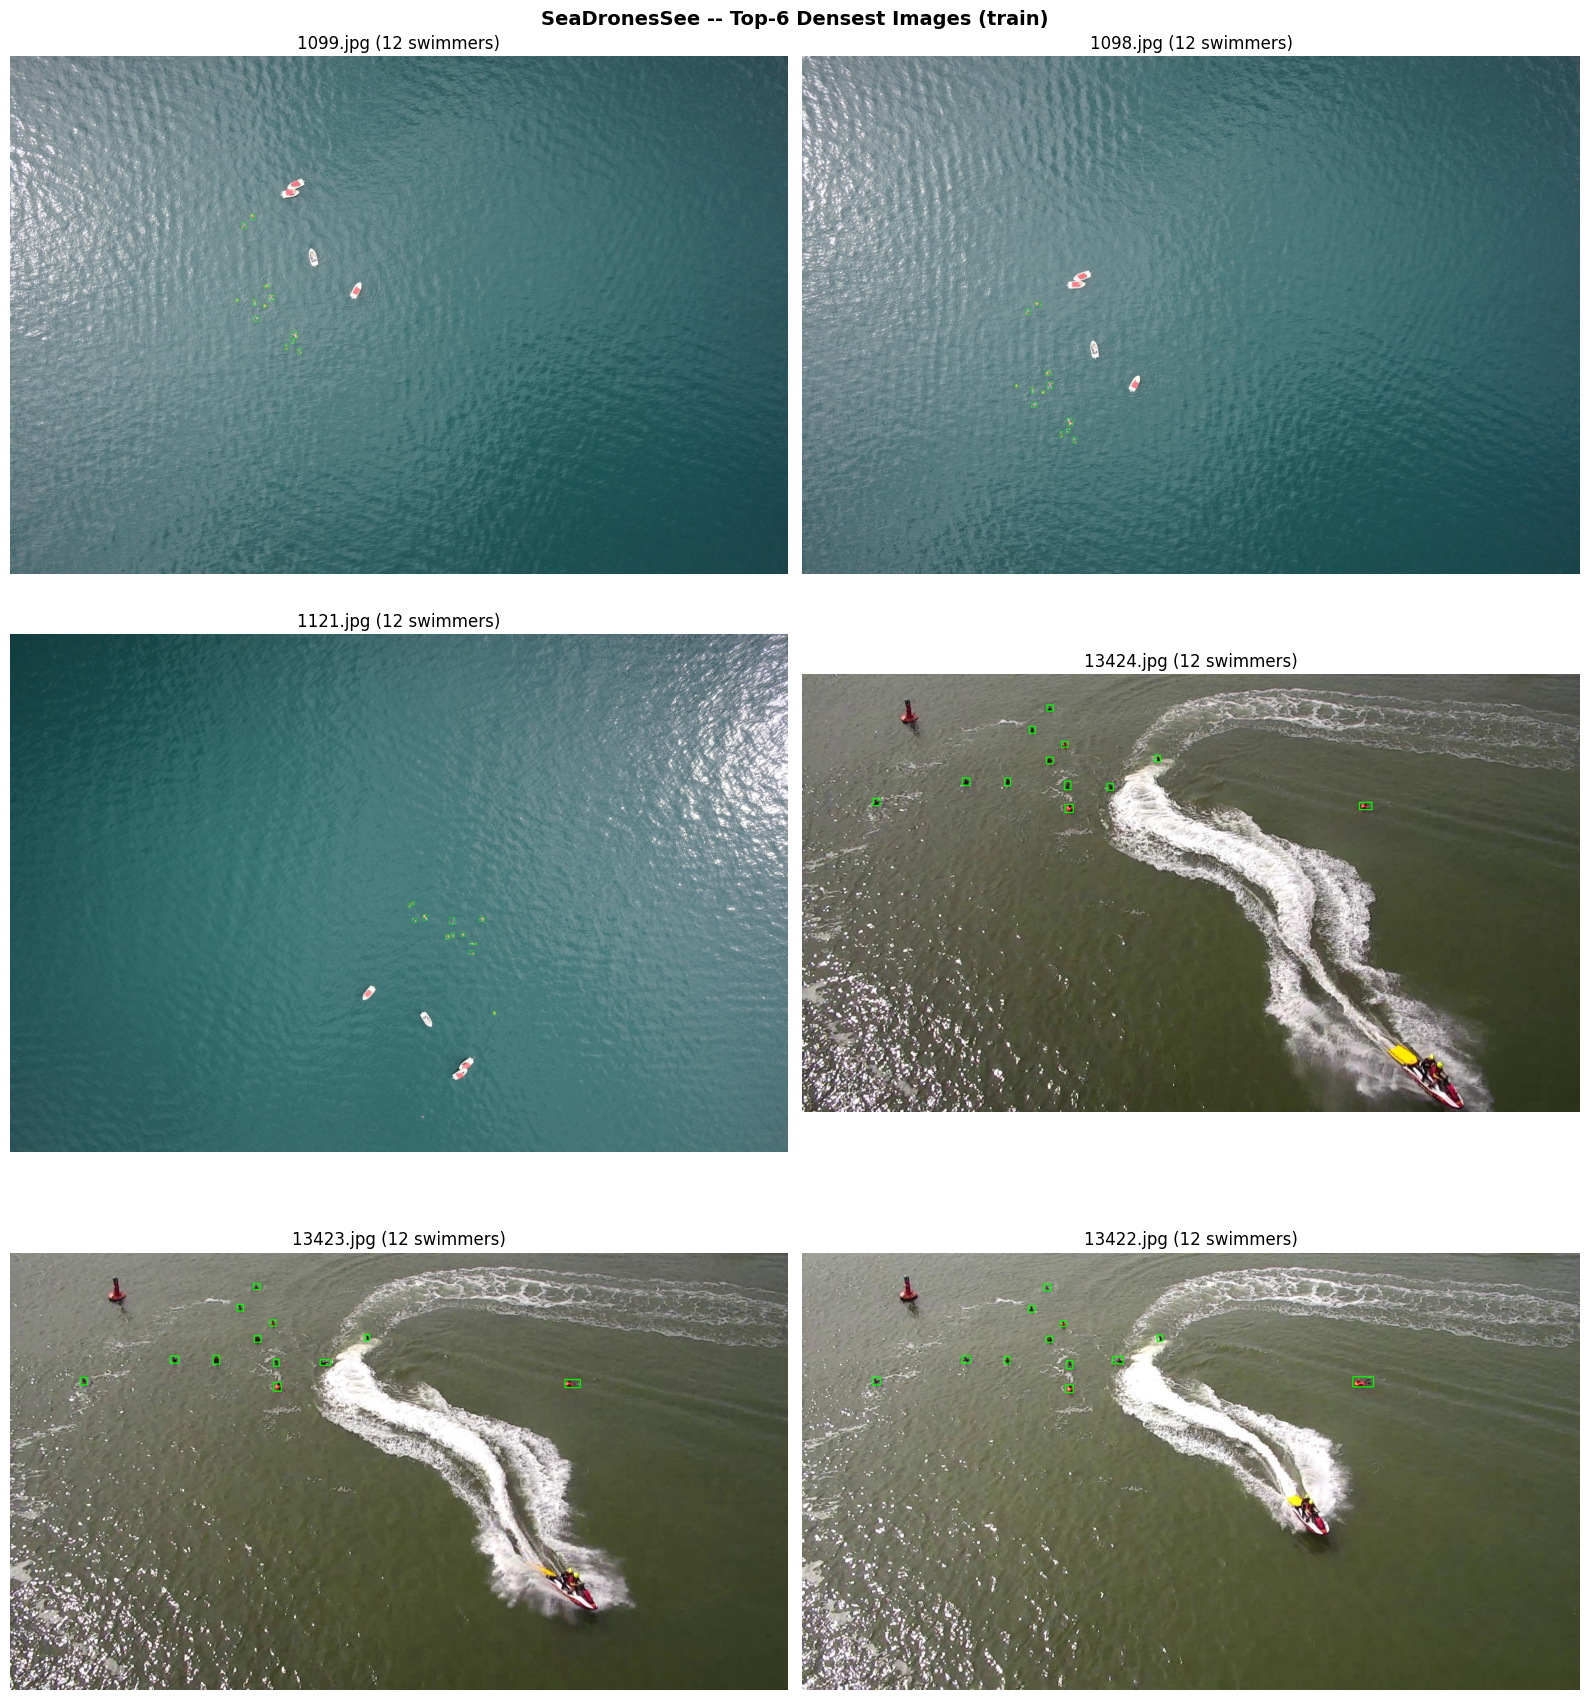

In [10]:
# Top-6 densest swimmer images (train)
top_imgs = (df_person[df_person['split']=='train']
            .groupby('file_name').size()
            .sort_values(ascending=False).head(6).index.tolist())

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, fname in enumerate(top_imgs):
    r, c = i // 2, i % 2
    img_path = os.path.join(TRAIN_IMG, fname)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    bboxes = df_person[df_person['file_name'] == fname]
    for _, b in bboxes.iterrows():
        x1, y1 = int(b['bbox_x']), int(b['bbox_y'])
        x2, y2 = x1 + int(b['bbox_w']), y1 + int(b['bbox_h'])
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    axes[r,c].imshow(img)
    axes[r,c].set_title(f'{fname} ({len(bboxes)} swimmers)')
    axes[r,c].axis('off')

plt.suptitle('SeaDronesSee -- Top-6 Densest Images (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
